---
**GUIA DE LABORATORIO 8 - Selección y extracción de características**  
**Nombre:** Roberto Roly Copa Mamani  
**Materia:** Machine Learning - INF 672

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [2]:
from sklearn.datasets import make_classification

X_syn, y_syn = make_classification(
    n_samples=400, n_features=10,
    n_informative=4, n_redundant=2, n_repeated=0,
    n_classes=2, shuffle=False, random_state=42)

cols = [f"f{i}" for i in range(10)]
X_syn_df = pd.DataFrame(X_syn, columns=cols)
VERDAD = {"informativas": [0,1,2,3], "redundantes": [4,5], "ruido": [6,7,8,9]}

In [3]:
from sklearn.datasets import load_iris

iris = load_iris()
X_iris, y_iris = iris.data, iris.target

In [4]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

vt = VarianceThreshold(threshold=0.0)
X_vt = vt.fit_transform(X_syn)

sel = SelectKBest(score_func=f_classif, k=4)
X_kbest = sel.fit_transform(X_syn, y_syn)
elegidas = np.where(sel.get_support())[0]

In [5]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

rfe = RFE(estimator=LogisticRegression(max_iter=1000),
          n_features_to_select=4)
rfe.fit(X_syn, y_syn)
elegidas_rfe = np.where(rfe.support_)[0]

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

rf = RandomForestClassifier(random_state=42).fit(X_syn, y_syn)
sel_rf = SelectFromModel(rf, threshold="median", prefit=True)
X_rf = sel_rf.transform(X_syn)

l1 = LogisticRegression(solver="saga", l1_ratio=1, C=0.1, max_iter=5000)
l1.fit(X_syn, y_syn)
sobreviven = np.where(np.abs(l1.coef_.ravel()) > 1e-6)[0]

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_esc = StandardScaler().fit_transform(X_iris)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_esc)
evr = pca.explained_variance_ratio_

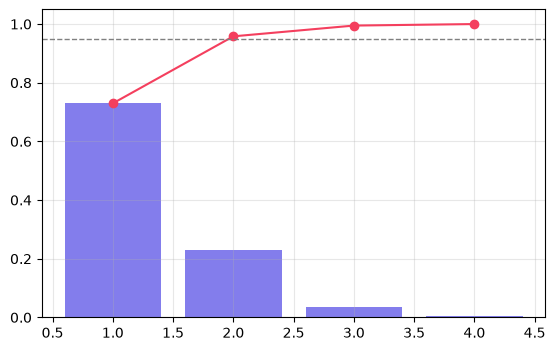

In [8]:
pca_full = PCA().fit(X_esc)
acum = np.cumsum(pca_full.explained_variance_ratio_)

x = np.arange(1, len(acum) + 1)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(x, pca_full.explained_variance_ratio_, color="#4F46E5", alpha=0.7)
ax.plot(x, acum, "o-", color="#F43F5E", label="acumulada")
ax.axhline(0.95, ls="--", color="gray", lw=1, label="umbral 95%")
plt.show()

In [9]:
from sklearn.manifold import TSNE

X_tsne = TSNE(n_components=2, perplexity=30,
              random_state=42).fit_transform(X_esc)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
base = make_pipeline(StandardScaler(),
LogisticRegression(max_iter=5000))
seleccion = make_pipeline(StandardScaler(),
SelectKBest(f_classif, k=10),
LogisticRegression(max_iter=5000))
extraccion = make_pipeline(StandardScaler(),
PCA(n_components=0.95),
LogisticRegression(max_iter=5000))

Elegiría la selección de características cuando necesite saber con claridad qué variables originales son realmente importantes para el modelo. En cambio, elegiría la extracción, como PCA, cuando tenga muchas variables y mi prioridad sea reducir dimensiones y trabajar de forma más eficiente, en el ejercicio final se observó que reducir de 30 características a aproximadamente 10, o conservar componentes con el 95 % de la varianza, casi no afectó la exactitud. Incluso, la reducción puede mejorar el rendimiento y hacer más rápido el entrenamiento del modelo, por eso, elegiría selección para explicar mejor los datos y extracción cuando busque principalmente compactar la información sin perder demasiado rendimiento.